# 🇱🇰 Sri Lanka Road Network — Full Network Junction-to-Junction Shortest-Path Distance Analysis

This notebook performs a network-wide analysis of shortest-path distances between road junctions in the Sri Lankan road network. Unlike experiments that focus on specific road classifications, this experiment considers **all reachable junctions** within the road network to establish baseline connectivity characteristics.

The notebook imports the CSV datasets exported by `sri_lanka_roads_interactive.ipynb` and constructs a weighted graph representing Sri Lanka's road network. Each road junction is treated as a graph node, while road segments are represented as weighted edges using their physical lengths.

The experiment computes the shortest-path distance between every reachable pair of junctions, producing comprehensive statistics that describe the overall structure, accessibility, and connectivity of the national road network. These results serve as a baseline for comparison with later experiments focusing on specific road classes, such as Class AA junctions.

## Methodology

1. Construct an undirected, weighted graph from the exported Sri Lankan road network.
   - Nodes represent road junctions and intersections.
   - Edges represent road segments weighted by physical length (meters).

2. For every junction in the network, execute Dijkstra's shortest-path algorithm to every other reachable junction.

3. Record the shortest-path distances and compute network-wide statistics, including:
   - Average shortest-path distance
   - Median distance
   - Minimum and maximum distances
   - Standard deviation
   - Reachability statistics

4. Generate visualizations illustrating the spatial characteristics of the network, including:
   - Histogram of shortest-path distances
   - Box plot
   - Cumulative distribution function (CDF)
   - Junction accessibility (centrality) heat map

5. Export per-junction metrics and summary statistics for subsequent analysis and comparison with other experiments.

## Required Input Files

The following datasets are produced by the export section of `sri_lanka_roads_interactive.ipynb` and should be located in `./data/` (or the directory specified by `DATA_DIR`):

- `sri_lanka_full_network_nodes.csv` — All nodes in the road network (`node_id`, `latitude`, `longitude`, `street_count`)
- `sri_lanka_full_network_edges.csv` — All road segments (`u`, `v`, `length_m`, ...)

In [2]:
# ── 0. Dependencies & Configuration ──────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import warnings
warnings.filterwarnings('ignore')

# Folder containing the 3 CSVs exported from the main notebook
DATA_DIR = "data"          # <- change this if your CSVs live elsewhere (e.g. "outputs")
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

NODES_PATH     = os.path.join(DATA_DIR, "sri_lanka_full_network_nodes.csv")
EDGES_PATH     = os.path.join(DATA_DIR, "sri_lanka_full_network_edges.csv")
JUNCTIONS_PATH = os.path.join(DATA_DIR, "sri_lanka_all_junctions_combined.csv")

for p in [NODES_PATH, EDGES_PATH, JUNCTIONS_PATH]:
    status = "✅ found" if os.path.exists(p) else "❌ MISSING"
    print(f"{status:12s} {p}")

print()
print("If any file is missing: run the main notebook's Section 9 export cell,")
print(f"then copy its outputs/ CSVs into '{DATA_DIR}/' (or update DATA_DIR above).")


✅ found      data\sri_lanka_full_network_nodes.csv
✅ found      data\sri_lanka_full_network_edges.csv
✅ found      data\sri_lanka_all_junctions_combined.csv

If any file is missing: run the main notebook's Section 9 export cell,
then copy its outputs/ CSVs into 'data/' (or update DATA_DIR above).


In [3]:
# ── 1. Load exported data ─────────────────────────────────────────────────
df_nodes     = pd.read_csv(NODES_PATH)
df_edges     = pd.read_csv(EDGES_PATH)
df_junctions = pd.read_csv(JUNCTIONS_PATH)

print(f"Full network nodes : {len(df_nodes):,}")
print(f"Full network edges : {len(df_edges):,}")
print(f"A-junctions (AA+B) : {len(df_junctions):,}")

df_nodes.head()


Full network nodes : 5,557
Full network edges : 12,031
A-junctions (AA+B) : 4,118


,node_id,latitude,longitude,street_count
0,31363877,6.057753,80.217612,4
1,33389197,5.948698,80.547196,3
2,33389255,5.973052,80.361972,3
3,33389341,5.942888,80.568388,3
4,33389417,5.928262,80.587898,3


---
## 2. Build the Graph

Undirected, weighted graph. Nodes are road junctions/intersections; edges are road segments
weighted by physical length in meters (`length_m`). OSMnx stores each two-way road as two
directed edges (u→v and v→u) — building an undirected `networkx.Graph` and keeping the
**minimum** length seen for any (u, v) pair de-duplicates this automatically, and also collapses
any parallel multi-edges down to the shortest physical connection between the two junctions.


In [4]:
# ── 2. Build undirected weighted graph ───────────────────────────────────────
G = nx.Graph()

# Node attributes: lat/lon + any available metadata
node_attrs = df_nodes.set_index('node_id').to_dict(orient='index')
for node_id, attrs in node_attrs.items():
    G.add_node(node_id, **attrs)

# Edges: keep the minimum length_m for any duplicate / parallel (u, v) pair
edge_min = (
    df_edges
    .dropna(subset=['u', 'v', 'length_m'])
    .groupby(['u', 'v'], as_index=False)['length_m']
    .min()
)

n_edges_added = 0
n_edges_skipped = 0
for _, row in edge_min.iterrows():
    u, v, w = row['u'], row['v'], row['length_m']
    if u == v or w <= 0:
        n_edges_skipped += 1
        continue
    if G.has_edge(u, v):
        # keep the shorter of the two directions if both appeared
        G[u][v]['weight'] = min(G[u][v]['weight'], w)
    else:
        G.add_edge(u, v, weight=w)
        n_edges_added += 1

print(f"Graph built: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"  edges skipped (self-loops / zero-length): {n_edges_skipped:,}")

# Restrict the "A" junction set to nodes that actually exist in the graph
junction_ids = [j for j in df_junctions['node_id'].unique() if j in G]
missing_junctions = len(df_junctions['node_id'].unique()) - len(junction_ids)
print(f"\nA-junctions present in graph: {len(junction_ids):,}"
      f"  ({missing_junctions} junction IDs from the CSV were not found in the graph and were dropped)")


Graph built: 5,557 nodes, 8,326 edges
  edges skipped (self-loops / zero-length): 1

A-junctions present in graph: 4,118  (0 junction IDs from the CSV were not found in the graph and were dropped)


---
## 3. Network-Wide Statistics


In [5]:
# ── 3. Network-wide statistics ────────────────────────────────────────────
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
components = list(nx.connected_components(G))
n_components = len(components)
largest_cc = max(components, key=len)

density = nx.density(G)
avg_degree = (2 * n_edges) / n_nodes if n_nodes else 0.0

network_stats = {
    "Number of junctions (nodes)":    n_nodes,
    "Number of road segments (edges)": n_edges,
    "Number of connected components":  n_components,
    "Largest component size":          len(largest_cc),
    "Graph density":                   density,
    "Average node degree":             avg_degree,
}

print("── Network-wide statistics ──")
for k, v in network_stats.items():
    print(f"  {k:35s}: {v:,.6f}" if isinstance(v, float) else f"  {k:35s}: {v:,}")


── Network-wide statistics ──
  Number of junctions (nodes)        : 5,557
  Number of road segments (edges)    : 8,326
  Number of connected components     : 19
  Largest component size             : 5,517
  Graph density                      : 0.000539
  Average node degree                : 2.996581


---
## 4. Experiment — Full Network Junction-to-Junction Shortest-Path Analysis

For every road junction in the Sri Lankan road network, Dijkstra's algorithm is executed to compute the shortest-path distance to every other reachable junction. The road network is represented as an undirected, weighted graph, where junctions are nodes, road segments are edges, and edge weights correspond to physical road lengths (meters).

This repeated single-source shortest-path approach has a computational complexity of **O(V · (E log V))** and is preferred over Floyd–Warshall due to the large size and sparse nature of the road network.

In [6]:
# ── 4. Run Dijkstra from every junction (A -> A) ─────────────────────────────
junction_set = set(junction_ids)

pair_records = []          # one row per ordered (A, A') reachable pair
per_junction_records = []  # one row per junction A

for i, source in enumerate(junction_ids):
    # Single-source Dijkstra over the full graph
    dist_map, path_map = nx.single_source_dijkstra(G, source, weight='weight')

    reachable_dists = []
    reachable_hops  = []
    for target in junction_ids:
        if target == source:
            continue
        if target in dist_map:
            d = dist_map[target]
            hops = len(path_map[target]) - 1
            pair_records.append((source, target, d, hops))
            reachable_dists.append(d)
            reachable_hops.append(hops)

    n_reachable   = len(reachable_dists)
    n_unreachable = (len(junction_ids) - 1) - n_reachable

    per_junction_records.append({
        "junction_id":       source,
        "latitude":          G.nodes[source].get("latitude", np.nan),
        "longitude":         G.nodes[source].get("longitude", np.nan),
        "reachable_nodes":   n_reachable,
        "unreachable_nodes": n_unreachable,
        "average_distance":  float(np.mean(reachable_dists)) if reachable_dists else np.nan,
        "maximum_distance":  float(np.max(reachable_dists))  if reachable_dists else np.nan,
        "average_hops":      float(np.mean(reachable_hops))  if reachable_hops  else np.nan,
    })

    if (i + 1) % 200 == 0 or (i + 1) == len(junction_ids):
        print(f"  processed {i + 1:,} / {len(junction_ids):,} source junctions...")

df_pairs = pd.DataFrame(pair_records, columns=["source", "target", "distance_m", "hops"])
df_per_junction = pd.DataFrame(per_junction_records)

print(f"\n✅ Computed shortest paths for {len(junction_ids):,} source junctions")
print(f"   Total reachable ordered pairs: {len(df_pairs):,}")


  processed 200 / 4,118 source junctions...
  processed 400 / 4,118 source junctions...
  processed 600 / 4,118 source junctions...
  processed 800 / 4,118 source junctions...
  processed 1,000 / 4,118 source junctions...
  processed 1,200 / 4,118 source junctions...
  processed 1,400 / 4,118 source junctions...
  processed 1,600 / 4,118 source junctions...
  processed 1,800 / 4,118 source junctions...
  processed 2,000 / 4,118 source junctions...
  processed 2,200 / 4,118 source junctions...
  processed 2,400 / 4,118 source junctions...
  processed 2,600 / 4,118 source junctions...
  processed 2,800 / 4,118 source junctions...
  processed 3,000 / 4,118 source junctions...
  processed 3,200 / 4,118 source junctions...
  processed 3,400 / 4,118 source junctions...
  processed 3,600 / 4,118 source junctions...
  processed 3,800 / 4,118 source junctions...
  processed 4,000 / 4,118 source junctions...
  processed 4,118 / 4,118 source junctions...

✅ Computed shortest paths for 4,118 sourc

---
## 5. Shortest-Path Statistics

Self-distances are excluded by construction (the loop above skips `target == source`).
Unreachable pairs are reported separately rather than included in the distance statistics.


In [7]:
# ── 5. Shortest-path statistics ───────────────────────────────────────────
distances_m = df_pairs["distance_m"].values
hops = df_pairs["hops"].values

n_possible_ordered_pairs = len(junction_ids) * (len(junction_ids) - 1)
n_reachable_pairs = len(df_pairs)
n_unreachable_pairs = n_possible_ordered_pairs - n_reachable_pairs

path_stats = {
    "Mean shortest-path distance (m)":   float(np.mean(distances_m)),
    "Median shortest-path distance (m)": float(np.median(distances_m)),
    "Minimum shortest-path distance (m)": float(np.min(distances_m)),
    "Maximum shortest-path distance (m)": float(np.max(distances_m)),
    "Standard deviation (m)":            float(np.std(distances_m)),
    "95th percentile distance (m)":      float(np.percentile(distances_m, 95)),
    "Mean hop count":                    float(np.mean(hops)),
    "Graph diameter (max shortest path, m)": float(np.max(distances_m)),
}

print("── Shortest-path statistics (junction A -> A, self-distances excluded) ──")
for k, v in path_stats.items():
    print(f"  {k:42s}: {v:,.2f}")

print()
print(f"  Reachable ordered pairs   : {n_reachable_pairs:,} / {n_possible_ordered_pairs:,}"
      f"  ({100 * n_reachable_pairs / n_possible_ordered_pairs:.2f}%)")
print(f"  Unreachable ordered pairs : {n_unreachable_pairs:,}"
      f"  ({100 * n_unreachable_pairs / n_possible_ordered_pairs:.2f}%)")


── Shortest-path statistics (junction A -> A, self-distances excluded) ──
  Mean shortest-path distance (m)           : 165,841.48
  Median shortest-path distance (m)         : 159,617.82
  Minimum shortest-path distance (m)        : 0.86
  Maximum shortest-path distance (m)        : 567,590.92
  Standard deviation (m)                    : 103,280.82
  95th percentile distance (m)              : 349,502.64
  Mean hop count                            : 87.05
  Graph diameter (max shortest path, m)     : 567,590.92

  Reachable ordered pairs   : 16,953,806 / 16,953,806  (100.00%)
  Unreachable ordered pairs : 0  (0.00%)


---
## 6. Per-Junction Statistics (Centrality Proxy)

`average_distance` and `maximum_distance` per junction were already computed during the Dijkstra
pass in Section 4. Lower average distance ⇒ more central; higher ⇒ more remote/isolated.


In [8]:
# ── 6. Per-junction statistics preview ───────────────────────────────────────
df_per_junction_sorted = df_per_junction.sort_values("average_distance")

print("Most central junctions (lowest average distance to all other junctions):")
display(df_per_junction_sorted.head(10))

print("\nMost remote/isolated junctions (highest average distance):")
display(df_per_junction_sorted.dropna(subset=["average_distance"]).tail(10))


Most central junctions (lowest average distance to all other junctions):


,junction_id,latitude,longitude,reachable_nodes,unreachable_nodes,average_distance,maximum_distance,average_hops
45,324965995,7.143891,80.095669,4117,0,115669.964309,378702.524318,71.009473
44,324965926,7.143901,80.095598,4117,0,115670.638415,378707.497418,71.019675
43,617823296,7.168521,80.124130,4117,0,115674.274471,374210.795693,66.357542
42,50366409,7.146537,80.097002,4117,0,115747.455661,378371.561340,71.038863
267,324966462,7.135859,80.089517,4117,0,115915.714345,379886.341402,71.543114
266,7786917078,7.135784,80.089554,4117,0,115915.854429,379889.483103,71.341268
2403,1723172809,7.112257,80.136276,4117,0,116447.863785,380908.262466,58.432597
2744,3120323405,7.097483,80.144685,4117,0,116482.171967,382921.636996,56.705611
2743,1235697764,7.097742,80.144641,4117,0,116483.370596,382892.609023,56.746903
483,667426156,7.126120,80.070626,4117,0,116488.523467,380509.887088,71.993442



Most remote/isolated junctions (highest average distance):


,junction_id,latitude,longitude,reachable_nodes,unreachable_nodes,average_distance,maximum_distance,average_hops
2796,1245033016,9.780131,79.988142,4117,0,364096.435757,553285.734278,127.490891
2792,7557813397,9.813498,80.014099,4117,0,365657.333251,554285.637478,122.573962
2791,1245021317,9.814308,80.012726,4117,0,365829.946295,554460.875447,123.563031
2797,1245033118,9.810232,79.997457,4117,0,367003.912379,556202.378670,127.918630
2789,1245021311,9.798181,79.958094,4117,0,367158.885640,556364.000607,129.488462
2578,847836026,9.637992,79.902008,4117,0,367242.455080,555835.900360,126.316493
2553,847419106,9.739689,79.889823,4117,0,368871.983048,557624.398005,133.040564
2579,13304847351,9.691118,79.870272,4117,0,371717.284597,560311.193487,126.316735
2554,1886574479,9.708812,79.866509,4117,0,373384.627445,562138.138768,134.040321
2619,871932407,9.583669,79.822054,4117,0,378994.620884,567590.921402,127.316250


---
## 7. Visualizations

### 7a. Histogram — Distribution of Shortest-Path Distances


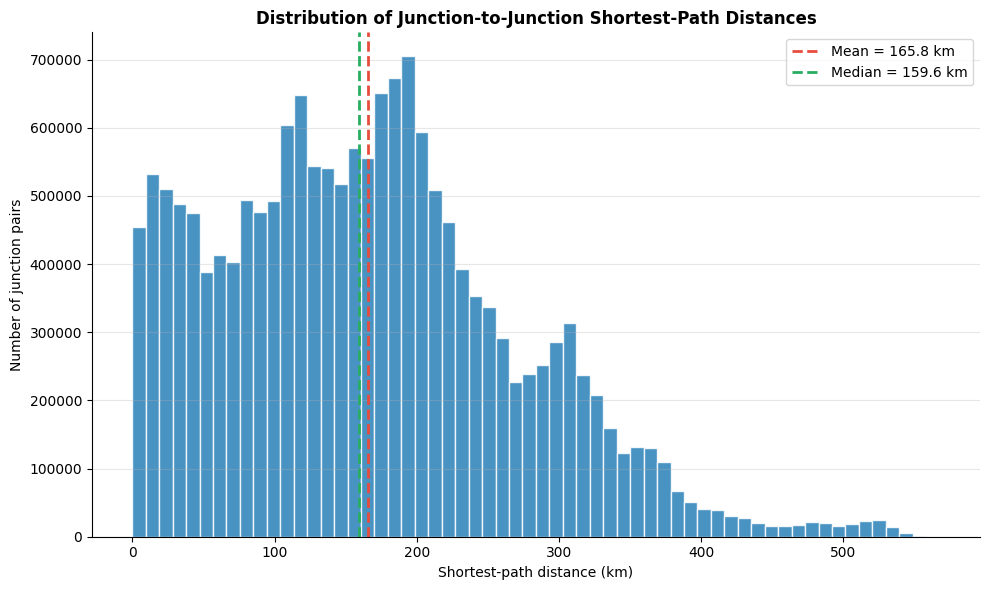

✅ Saved outputs/chart_distance_histogram.png


In [9]:
# ── 7a. Histogram ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(distances_m / 1000, bins=60, color="#2980b9", edgecolor="white", alpha=0.85)
ax.axvline(np.mean(distances_m) / 1000, color="#e74c3c", linestyle="--", linewidth=2,
           label=f"Mean = {np.mean(distances_m)/1000:.1f} km")
ax.axvline(np.median(distances_m) / 1000, color="#27ae60", linestyle="--", linewidth=2,
           label=f"Median = {np.median(distances_m)/1000:.1f} km")
ax.set_xlabel("Shortest-path distance (km)")
ax.set_ylabel("Number of junction pairs")
ax.set_title("Distribution of Junction-to-Junction Shortest-Path Distances", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_distance_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved {OUTPUT_DIR}/chart_distance_histogram.png")


### 7b. Box Plot — Shortest-Path Distance Distribution

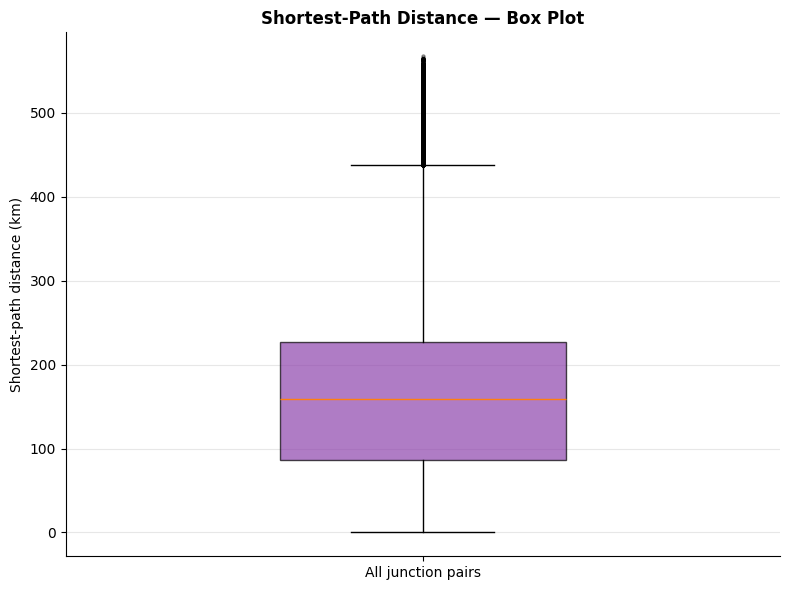

✅ Saved outputs/chart_distance_boxplot.png


In [10]:
# ── 7b. Box plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(distances_m / 1000, vert=True, patch_artist=True, widths=0.4,
                 showfliers=True, flierprops=dict(marker='o', markersize=2, alpha=0.3))
for box in bp['boxes']:
    box.set_facecolor("#8e44ad")
    box.set_alpha(0.7)
ax.set_ylabel("Shortest-path distance (km)")
ax.set_xticks([1])
ax.set_xticklabels(["All junction pairs"])
ax.set_title("Shortest-Path Distance — Box Plot", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_distance_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved {OUTPUT_DIR}/chart_distance_boxplot.png")


### 7c. Heat Map — Junction Centrality

Junctions colored by their average distance to all other junctions:
🟢 green = very central, 🟡 yellow = average, 🔴 red = isolated.


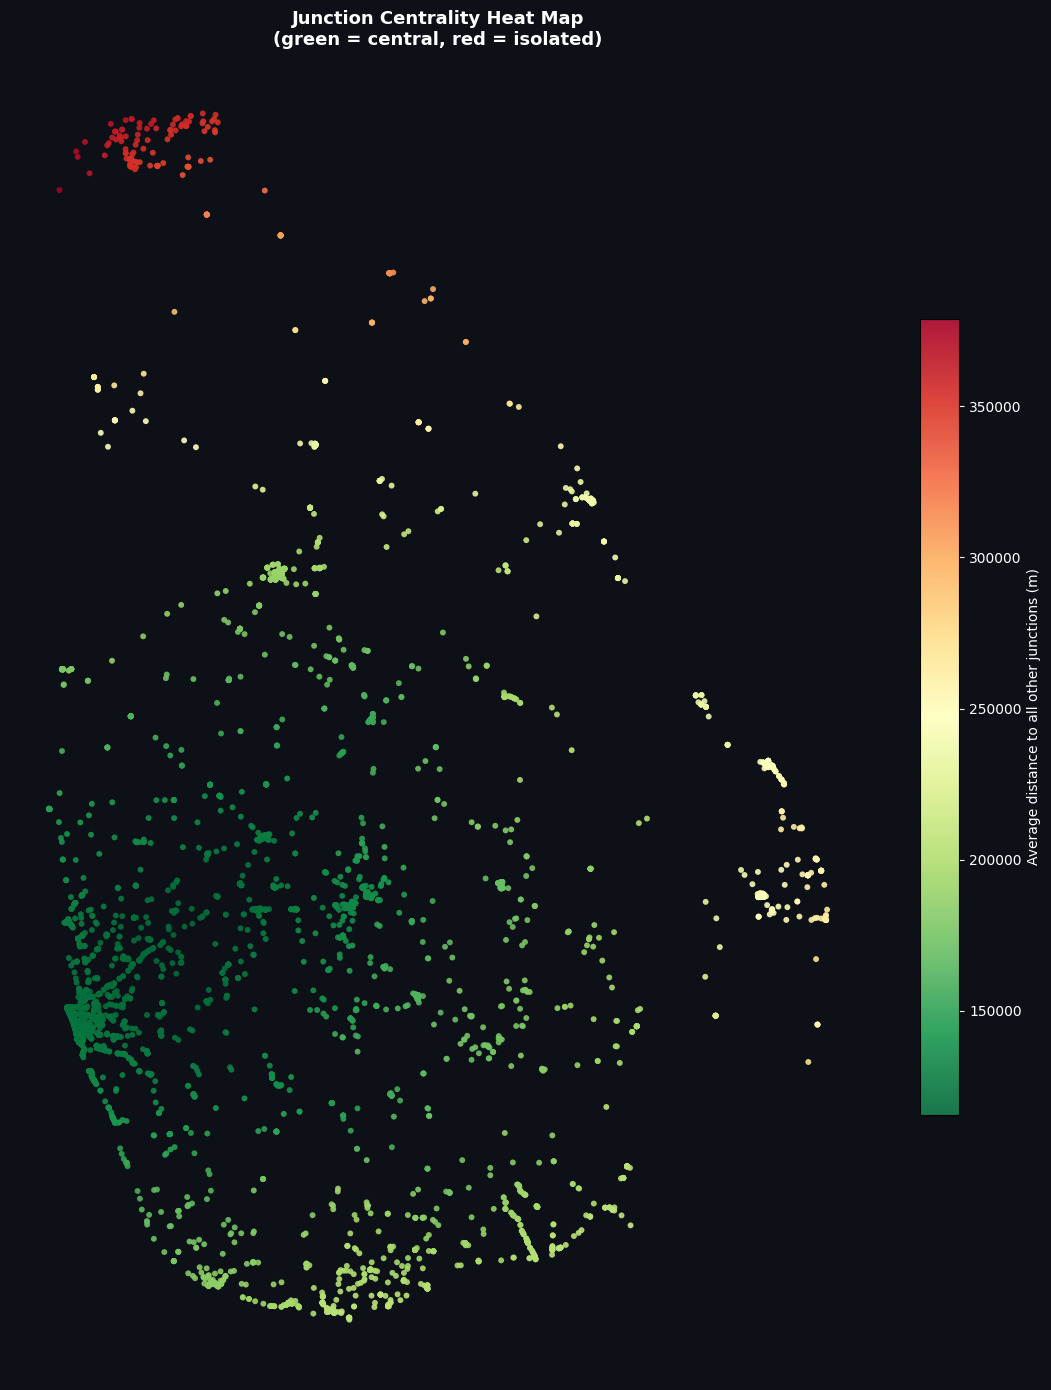

✅ Saved outputs/chart_centrality_heatmap.png


In [11]:
# ── 7c. Centrality heat map (static, matplotlib) ─────────────────────────────
plot_df = df_per_junction.dropna(subset=["average_distance", "latitude", "longitude"])

fig, ax = plt.subplots(figsize=(11, 14), facecolor="#0d1117")
ax.set_facecolor("#0d1117")

norm = mcolors.Normalize(vmin=plot_df["average_distance"].min(),
                          vmax=plot_df["average_distance"].max())
cmap = cm.get_cmap("RdYlGn_r")   # green (low/central) -> red (high/isolated)

sc = ax.scatter(plot_df["longitude"], plot_df["latitude"],
                 c=plot_df["average_distance"], cmap=cmap, norm=norm,
                 s=18, alpha=0.9, edgecolors="none")

cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label("Average distance to all other junctions (m)", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

ax.set_title("Junction Centrality Heat Map\n(green = central, red = isolated)",
             color="white", fontweight="bold", fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_centrality_heatmap.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved {OUTPUT_DIR}/chart_centrality_heatmap.png")


### 7c (interactive). Centrality Heat Map — Folium

An interactive Leaflet version of the same centrality heat map: click any junction to see its
exact average and maximum distance.


In [12]:
# ── 7c-interactive. Folium centrality map ────────────────────────────────────
import folium
import matplotlib.colors as mcolors

m = folium.Map(
    location=[plot_df["latitude"].mean(), plot_df["longitude"].mean()],
    zoom_start=8, tiles="CartoDB dark_matter", control_scale=True,
)

vmin, vmax = plot_df["average_distance"].min(), plot_df["average_distance"].max()
cmap = cm.get_cmap("RdYlGn_r")

for _, row in plot_df.iterrows():
    frac = (row["average_distance"] - vmin) / (vmax - vmin) if vmax > vmin else 0.5
    color = mcolors.to_hex(cmap(frac))
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=4, color=color, weight=1, fill=True, fill_color=color, fill_opacity=0.85,
        popup=(f"<b>Junction {int(row['junction_id'])}</b><br>"
               f"Avg distance: {row['average_distance']/1000:.1f} km<br>"
               f"Max distance: {row['maximum_distance']/1000:.1f} km<br>"
               f"Reachable junctions: {int(row['reachable_nodes'])}"),
    ).add_to(m)

interactive_map_path = f"{OUTPUT_DIR}/junction_centrality_map.html"
m.save(interactive_map_path)
print(f"✅ Interactive centrality map saved -> {interactive_map_path}")
m


✅ Interactive centrality map saved -> outputs/junction_centrality_map.html


### 7d. Cumulative Distribution — Junction Pairs vs. Shortest-Path Distance

In [13]:
# ── 7d. Cumulative distribution ───────────────────────────────────────────
sorted_d = np.sort(distances_m) / 1000
cum_pct = np.arange(1, len(sorted_d) + 1) / len(sorted_d) * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sorted_d, cum_pct, color="#16a085", linewidth=2)
ax.fill_between(sorted_d, cum_pct, alpha=0.15, color="#16a085")
ax.axhline(95, color="#e74c3c", linestyle="--", linewidth=1,
           label=f"95th percentile = {path_stats['95th percentile distance (m)']/1000:.1f} km")
ax.set_xlabel("Shortest-path distance (km)")
ax.set_ylabel("Cumulative percentage of junction pairs (%)")
ax.set_title("Cumulative Distribution of Junction-to-Junction Distances", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_cumulative_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved {OUTPUT_DIR}/chart_cumulative_distribution.png")


MemoryError: Unable to allocate 64.7 MiB for an array with shape (33907615, 2) and data type bool

Error in callback <function _draw_all_if_interactive at 0x000001D0FB51A0C0> (for post_execute), with arguments args (),kwargs {}:


MemoryError: Unable to allocate 517. MiB for an array with shape (33907615, 2) and data type float64

MemoryError: Unable to allocate 517. MiB for an array with shape (33907615, 2) and data type float64

<Figure size 1000x600 with 1 Axes>

---
## 8. Outputs

### 8a. Per-Junction CSV


In [ ]:
# ── 8a. Per-junction CSV ──────────────────────────────────────────────────
csv_export = df_per_junction[[
    "junction_id", "latitude", "longitude",
    "reachable_nodes", "average_distance", "maximum_distance",
]].rename(columns={"junction_id": "junction_id"})
csv_export = csv_export.round({"latitude": 6, "longitude": 6,
                                "average_distance": 2, "maximum_distance": 2})

per_junction_path = f"{OUTPUT_DIR}/junction_distance_stats.csv"
csv_export.to_csv(per_junction_path, index=False)
print(f"✅ Per-junction CSV -> {per_junction_path}  ({len(csv_export):,} rows)")

# Also save the raw pairwise distance table (useful for later experiments,
# e.g. betweenness centrality / robustness simulations)
pairs_path = f"{OUTPUT_DIR}/junction_pairwise_distances.csv"
df_pairs.to_csv(pairs_path, index=False)
print(f"✅ Pairwise distance table -> {pairs_path}  ({len(df_pairs):,} rows)")


✅ Per-junction CSV -> outputs/junction_distance_stats.csv  (4,118 rows)
✅ Pairwise distance table -> outputs/junction_pairwise_distances.csv  (16,953,806 rows)


### 8b. Summary Report

In [ ]:
# ── 8b. Summary report ────────────────────────────────────────────────────
print("=" * 65)
print("  SRI LANKA ROAD NETWORK — FULL NETWORK JUNCTION DISTANCE EXPERIMENT")
print("=" * 65)
print()
print(f"  Nodes (junctions analysed)   : {n_nodes:,}")
print(f"  Edges (road segments, full graph) : {n_edges:,}")
print(f"  Connected components         : {n_components:,}")
print(f"  Average degree               : {avg_degree:.3f}")
print(f"  Graph density                : {density:.6f}")
print()
print(f"  Average shortest-path distance : {path_stats['Mean shortest-path distance (m)']/1000:.2f} km")
print(f"  Median distance                : {path_stats['Median shortest-path distance (m)']/1000:.2f} km")
print(f"  Maximum distance               : {path_stats['Maximum shortest-path distance (m)']/1000:.2f} km")
print(f"  Minimum distance               : {path_stats['Minimum shortest-path distance (m)']/1000:.2f} km")
print(f"  Standard deviation             : {path_stats['Standard deviation (m)']/1000:.2f} km")
print(f"  Graph diameter (max obs.)      : {path_stats['Graph diameter (max shortest path, m)']/1000:.2f} km")
print()
print(f"  Reachable junction pairs       : {n_reachable_pairs:,} / {n_possible_ordered_pairs:,} "
      f"({100*n_reachable_pairs/n_possible_ordered_pairs:.2f}%)")
print(f"  Unreachable junction pairs     : {n_unreachable_pairs:,}")
print()
print("  Most central junction  :",
      f"id={df_per_junction_sorted.iloc[0]['junction_id']:.0f}",
      f"(avg dist {df_per_junction_sorted.iloc[0]['average_distance']/1000:.1f} km)")
print("  Most isolated junction :",
      f"id={df_per_junction_sorted.dropna(subset=['average_distance']).iloc[-1]['junction_id']:.0f}",
      f"(avg dist {df_per_junction_sorted.dropna(subset=['average_distance']).iloc[-1]['average_distance']/1000:.1f} km)")
print("=" * 65)


  SRI LANKA ROAD NETWORK — FULL NETWORK JUNCTION DISTANCE EXPERIMENT



NameError: name 'n_nodes' is not defined

---
## 9. Research Questions — Answered from the Data Above

1. **How well connected is the network?** See *Section 3* (connected components, density,
   average degree) and the reachable-pairs percentage in *Section 5/8b*.
2. **Average travel distance between two arbitrary junctions?** `Mean shortest-path distance`
   in *Section 5/8b*.
3. **Which junctions are most central / remote?** *Section 6* and the heat maps in *Section 7c*.
4. **Which regions look isolated?** Red clusters on the heat map (*Section 7c*) and the tail of
   the per-junction table sorted by `average_distance` (*Section 6*).
5. **Efficient connectivity or excessive path lengths?** Compare the mean/median distance and the
   shape of the cumulative distribution (*Section 7d*) against the network's geographic extent —
   a long right tail or a mean far above the median suggests inefficiently long detours for some
   junction pairs.

This per-junction CSV and pairwise distance table are saved so they can be reused directly for
follow-up experiments: betweenness centrality, articulation-point detection, or network
robustness/failure simulations.
